# Analyse profile-generation predictions

Score Qwen3.5 0.8b / 2b / 4b profile generation (contact extracts) against ground truth: 

Metrics:
- field recall,
- field hallucination
- LLM-judge pass rate for `profile_text`. 

Write to `eval/results/profile_generation_results.csv`, then visualise.

## 0. Setup


In [25]:
# %pip install -q pandas matplotlib

In [26]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Resolve repo root whether the kernel cwd is repo root or eval/analysis/
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "analysis":
    # Notebook opened from eval/analysis/
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "eval").is_dir():
    # Already at repo root
    pass
else:
    # Walk up until we find eval/predictions/
    for p in [REPO_ROOT, *REPO_ROOT.parents]:
        if (p / "eval" / "predictions").is_dir():
            REPO_ROOT = p
            break

# Define paths
GT_PATH = REPO_ROOT / "eval" / "datasets" / "ground_truths" / "profile_generation.jsonl"
PRED_DIR = REPO_ROOT / "eval" / "predictions" / "profile_generation"
JUDGE_DIR = REPO_ROOT / "eval" / "judgements" / "profile_generation"
RESULTS_DIR = REPO_ROOT / "eval" / "results"
RESULTS_CSV = RESULTS_DIR / "profile_generation_results.csv"

# Models to load
MODELS = ["qwen3.5_0.8b", "qwen3.5_2b", "qwen3.5_4b"]

# Structured fields to be scored with containment (excluding profile_text / keywords)
STRUCTURED_FIELDS = [
    "display_name",
    "email",
    "phone",
    "company",
    "role",
    "location",
]

print("REPO_ROOT:", REPO_ROOT)
print("GT:", GT_PATH.exists(), GT_PATH)
print("PRED_DIR:", PRED_DIR)
print("JUDGE_DIR:", JUDGE_DIR)

REPO_ROOT: /Users/desmond/Documents/University/Y3/FP/imet
GT: True /Users/desmond/Documents/University/Y3/FP/imet/eval/datasets/ground_truths/profile_generation.jsonl
PRED_DIR: /Users/desmond/Documents/University/Y3/FP/imet/eval/predictions/profile_generation
JUDGE_DIR: /Users/desmond/Documents/University/Y3/FP/imet/eval/judgements/profile_generation


## 1. Load

Read the prediction JSONLs, join ground truth on `id`, dump into one DataFrame.


In [27]:
def load_jsonl(path: Path) -> list[dict]:
    """
    Load rows from a JSONL file then convert into a list of dictionaries.
    """
    rows: list[dict] = []

    # Read file line by line
    for line in path.read_text(encoding="utf-8").splitlines():
        # Skip empty lines
        if not line.strip():
            continue
        # Parse JSON and add to list
        rows.append(json.loads(line))

    return rows


# Load ground truth and index by id for joining
gt_rows = load_jsonl(GT_PATH)
gt_by_id = {int(r["id"]): r["expected"] for r in gt_rows}

# Load each model's predictions and join expected fields on id
pred_rows: list[dict] = []
for model in MODELS:
    pred_path = PRED_DIR / f"{model}.jsonl"
    # Skip models that have not been run yet
    if not pred_path.is_file():
        print(f"missing: {pred_path}")
        continue

    for row in load_jsonl(pred_path):
        row_id = int(row["id"])
        pred_rows.append({
            "model": row.get("model") or model,
            "id": row_id,
            "prediction": row.get("prediction") or {},
            "latency_ms": row.get("latency_ms"),
            "error": row.get("error"),
            "expected": gt_by_id.get(row_id),
        })

# Dump into one DataFrame
pred_df = pd.DataFrame(pred_rows)
print(pred_df.shape)
pred_df.head()

(90, 6)


,model,id,prediction,latency_ms,error,expected
0,qwen3.5_0.8b,1,"{'display_name': None, 'email': None, 'phone':...",4717.31,None,"{'display_name': 'Margot Calder', 'email': 'ma..."
1,qwen3.5_0.8b,2,"{'display_name': None, 'email': None, 'phone':...",2938.87,None,"{'display_name': 'Otto Brandt', 'email': 'otto..."
2,qwen3.5_0.8b,3,"{'display_name': None, 'email': None, 'phone':...",2693.69,None,"{'display_name': 'Priya Raghunathan', 'email':..."
3,qwen3.5_0.8b,4,"{'display_name': None, 'email': None, 'phone':...",3395.97,None,"{'display_name': 'Gwendolyn A. Parr', 'email':..."
4,qwen3.5_0.8b,5,"{'display_name': None, 'email': None, 'phone':...",3268.22,None,"{'display_name': 'Lena Frei', 'email': 'lena@n..."


## 2. Score structured fields

* Field recall: Considered a hit if the expected value is contained in the prediction after normalisation (lowercase / collapsed whitespace, Phones compare digits only).

* Field hallucination: Considered a hallucination when the expected field is empty, but the model still invented a value.


In [28]:
# Treat these as empty after normalisation
_NULL_STRINGS = {"", "null", "none", "unknown", "n/a"}


def is_null(value) -> bool:
    """
    True if the field is missing / empty / a null-like string.
    """
    if value is None:
        return True
    if not isinstance(value, str):
        return False
    return value.strip().lower() in _NULL_STRINGS


def norm_text(s: str) -> str:
    """
    Lowercase and collapse whitespace.
    e.g. " John\n Smith " becomes "john smith"
    """
    return " ".join(s.lower().split())


def digits_only(s: str) -> str:
    """
    Keep digits only (used for phone matching across spaces, +, dashes).
    e.g. "+123 456-7890" becomes "1234567890"
    """
    return "".join(c for c in s if c.isdigit())


def field_hit(field: str, gt_value: str, pred_value) -> bool:
    """
    True if the expected value appears in the predicted field after light normalisation.

    Phones: digit-only substring (handles spaces, +, dashes).
    Other fields: lowercased, collapsed-whitespace substring.
    """
    # Empty prediction cannot contain the expected value
    if is_null(pred_value):
        return False

    pred_text = str(pred_value)

    # Phone: compare digits only so formatting differences do not matter
    if field == "phone":
        gt_digits = digits_only(gt_value)
        pred_digits = digits_only(pred_text)
        return bool(gt_digits) and gt_digits in pred_digits

    # Default: lowercased and collapsed whitespace substring match
    gt_norm = norm_text(gt_value)
    pred_norm = norm_text(pred_text)
    if not gt_norm:
        return False

    return gt_norm in pred_norm

In [29]:
recall_rows: list[dict] = []
hallucination_rows: list[dict] = []

# Score every structured field on every prediction row
for row in pred_df.itertuples(index=False):
    expected = row.expected
    # Skip rows with missing expected
    if not isinstance(expected, dict):
        continue

    prediction = row.prediction or {}

    for field in STRUCTURED_FIELDS:
        gt_value = expected.get(field)
        pred_value = prediction.get(field)

        # Field recall: only score when expected has a value
        if not is_null(gt_value):
            recall_rows.append({
                "model": row.model,
                "id": row.id,
                "field": field,
                "hit": int(field_hit(field, str(gt_value), pred_value)),
                "latency_ms": row.latency_ms,
            })

        # Field hallucination: only score when expected is genuinely null
        if is_null(gt_value):
            hallucination_rows.append({
                "model": row.model,
                "id": row.id,
                "field": field,
                "invented": int(not is_null(pred_value)),
                "latency_ms": row.latency_ms,
            })

recall_df = pd.DataFrame(recall_rows)
hallucination_df = pd.DataFrame(hallucination_rows)
print(recall_df.shape, hallucination_df.shape)
recall_df.head()

(399, 5) (141, 5)


,model,id,field,hit,latency_ms
0,qwen3.5_0.8b,1,display_name,0,4717.31
1,qwen3.5_0.8b,1,email,0,4717.31
2,qwen3.5_0.8b,1,phone,1,4717.31
3,qwen3.5_0.8b,1,company,1,4717.31
4,qwen3.5_0.8b,1,role,1,4717.31


## 3. Load profile-text judgements

Binary pass/fail from `eval/judgement/profile_generation/{model}.jsonl`.


Rows with null value on `pass` field (`profile_text` does not exist) are dropped from the pass rate.

In [30]:
judge_rows: list[dict] = []
for model in MODELS:
    path = JUDGE_DIR / f"{model}.jsonl"
    # Skip models that have not been judged yet
    if not path.is_file():
        print(f"missing: {path}")
        continue
    judge_rows.extend(load_jsonl(path))

# Convert to DataFrame
judge_df = pd.DataFrame(judge_rows)
if judge_df.empty:
    print("No judgement files yet. Run run_profile_judge.py first.")
else:
    print(judge_df.shape)

(90, 4)


In [31]:
judge_df

,id,model,pass,error
0,1,qwen3.5_0.8b,False,NaN
1,2,qwen3.5_0.8b,False,NaN
2,3,qwen3.5_0.8b,False,NaN
3,4,qwen3.5_0.8b,False,NaN
4,5,qwen3.5_0.8b,False,NaN
...,...,...,...,...
85,26,qwen3.5_4b,False,NaN
86,27,qwen3.5_4b,True,NaN
87,28,qwen3.5_4b,False,NaN
88,29,qwen3.5_4b,None,empty profile_text


## 4. Aggregate and save

One row per `(model, metric)` in `eval/results/profile_generation_results.csv`.


In [32]:
result_rows: list[dict] = []

# Mean latency per model from prediction rows (one latency per capture)
latency = (
    pred_df.groupby("model", as_index=False)
    .agg(latency_ms_mean=("latency_ms", "mean"))
    .set_index("model")["latency_ms_mean"]
)

for model in MODELS:
    latency_ms_mean = float(latency[model]) if model in latency.index else None

    # Field recall: mean hit over all non-null expected field instances
    rec = recall_df[recall_df["model"] == model]
    result_rows.append({
        "model": model,
        "metric": "field_recall",
        "value": float(rec["hit"].mean()) if len(rec) else None,
        "latency_ms_mean": latency_ms_mean,
    })

    # Hallucination rate: mean invented over genuinely null expected fields
    hallucination = hallucination_df[hallucination_df["model"] == model]
    result_rows.append({
        "model": model,
        "metric": "hallucination_rate",
        "value": float(hallucination["invented"].mean()) if len(hallucination) else None,
        "latency_ms_mean": latency_ms_mean,
    })

    # Profile-text pass rate from the judge JSONL
    if not judge_df.empty:
        judged = judge_df[
            (judge_df["model"] == model) & (judge_df["pass"].isin([True, False]))
        ]
        result_rows.append({
            "model": model,
            "metric": "profile_pass_rate",
            "value": float(judged["pass"].mean()) if len(judged) else None,
            "latency_ms_mean": latency_ms_mean,
        })

results = pd.DataFrame(result_rows)
results

,model,metric,value,latency_ms_mean
0,qwen3.5_0.8b,field_recall,0.488722,2498.150333
1,qwen3.5_0.8b,hallucination_rate,0.148936,2498.150333
2,qwen3.5_0.8b,profile_pass_rate,0.033333,2498.150333
3,qwen3.5_2b,field_recall,0.789474,5180.098333
4,qwen3.5_2b,hallucination_rate,0.170213,5180.098333
5,qwen3.5_2b,profile_pass_rate,0.200000,5180.098333
6,qwen3.5_4b,field_recall,0.842105,9376.574667
7,qwen3.5_4b,hallucination_rate,0.085106,9376.574667
8,qwen3.5_4b,profile_pass_rate,0.428571,9376.574667


In [33]:
# Ensure output directory exists for the results file
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Write to CSV
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {len(results)} rows to {RESULTS_CSV.relative_to(REPO_ROOT)}")

Wrote 9 rows to eval/results/profile_generation_results.csv


## 5. Visualisation

1. Field recall by field
2. Hallucination rate per model
3. Profile-text pass rate per model
4. Latency vs metrics


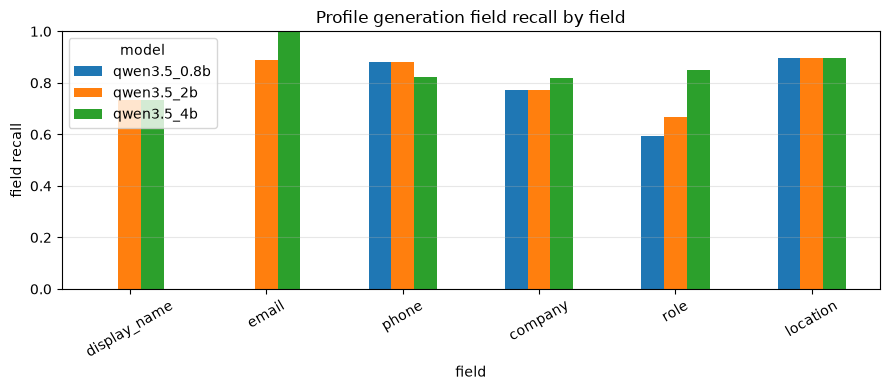

In [34]:
# 1. Field recall by field
by_field = (
    recall_df.groupby(["model", "field"], as_index=False)
    .agg(n=("hit", "size"), hits=("hit", "sum"), recall=("hit", "mean"))
)
pivot_recall_field = by_field.pivot(index="field", columns="model", values="recall")
pivot_recall_field = pivot_recall_field.reindex(
    index=STRUCTURED_FIELDS, columns=MODELS
)

ax = pivot_recall_field.plot(kind="bar", figsize=(9, 4), rot=30)
ax.set_ylabel("field recall")
ax.set_xlabel("field")
ax.set_title("Profile generation field recall by field")
ax.set_ylim(0, 1)
ax.legend(title="model")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

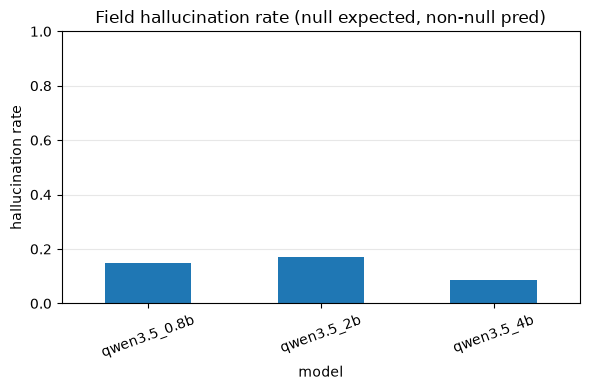

In [35]:
# 2. Hallucination rate per model
hall_by_model = (
    hallucination_df.groupby("model", as_index=False)
    .agg(hallucination_rate=("invented", "mean"))
    .set_index("model")
    .reindex(MODELS)
)

ax = hall_by_model["hallucination_rate"].plot(kind="bar", figsize=(6, 4), rot=20)
ax.set_ylabel("hallucination rate")
ax.set_ylim(0, 1)
ax.set_title("Field hallucination rate (null expected, non-null pred)")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

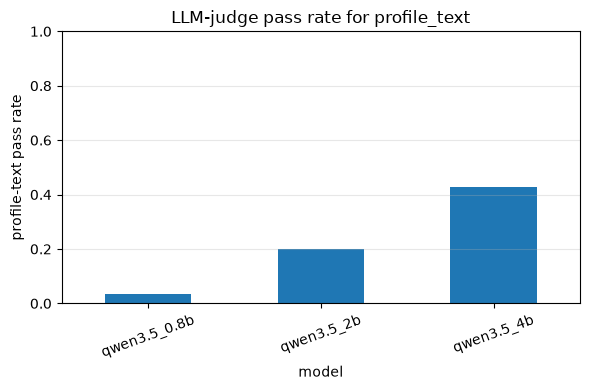

In [36]:
# 3. Profile-text pass rate per model
if judge_df.empty:
    print("Skip pass-rate plot: no judgement files.")
else:
    pass_by_model = (
        judge_df[judge_df["pass"].isin([True, False])]
        .groupby("model", as_index=False)
        .agg(profile_pass_rate=("pass", "mean"))
        .set_index("model")
        .reindex(MODELS)
    )

    ax = pass_by_model["profile_pass_rate"].plot(kind="bar", figsize=(6, 4), rot=20)
    ax.set_ylabel("profile-text pass rate")
    ax.set_ylim(0, 1)
    ax.set_title("LLM-judge pass rate for profile_text")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

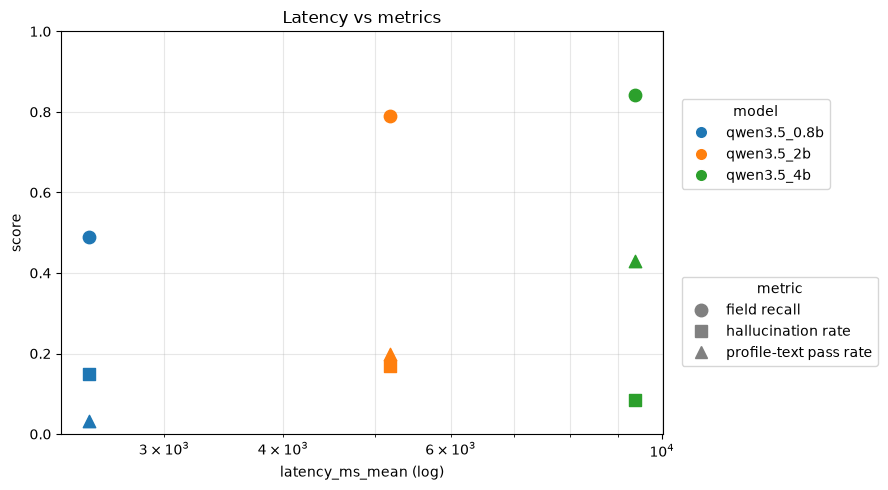

In [37]:
# 4. Latency vs metrics scatter
from matplotlib.lines import Line2D

MARKERS = {
    "field_recall": "o",
    "hallucination_rate": "s",
    "profile_pass_rate": "^",
}
metric_labels = {
    "field_recall": "field recall",
    "hallucination_rate": "hallucination rate",
    "profile_pass_rate": "profile-text pass rate",
}
metrics_present = [m for m in MARKERS if m in set(results["metric"])]

fig, ax = plt.subplots(figsize=(9, 5))

for i, model in enumerate(MODELS):
    m = results[results["model"] == model]
    for _, row in m.iterrows():
        if pd.isna(row["value"]):
            continue
        ax.scatter(
            row["latency_ms_mean"],
            row["value"],
            color=f"C{i}",
            marker=MARKERS[row["metric"]],
            s=80,
            zorder=3,
            label="_nolegend_",
        )

# Legends: colour = model, shape = metric
model_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=f"C{i}", markersize=9, label=m)
    for i, m in enumerate(MODELS)
]
metric_handles = [
    Line2D(
        [0], [0],
        marker=MARKERS[k],
        color="gray",
        linestyle="None",
        markersize=9,
        label=metric_labels[k],
    )
    for k in metrics_present
]
leg1 = ax.legend(
    handles=model_handles,
    title="model",
    loc="center left",
    bbox_to_anchor=(1.02, 0.72),
)
ax.add_artist(leg1)
ax.legend(
    handles=metric_handles,
    title="metric",
    loc="center left",
    bbox_to_anchor=(1.02, 0.28),
)

ax.set_xscale("log")
ax.set_xlabel("latency_ms_mean (log)")
ax.set_ylabel("score")
ax.set_ylim(0, 1)
ax.set_title("Latency vs metrics")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()